# ML Solubility Prediction Project
## Notebook 02: SMILES, RDKit Descriptors and Morgan Fingerprints

**Author:** Samson Khunga  
**Date:** 29/03/2026  
**Builds on:** Notebook 01 (data/esol_raw.csv, 1128 rows, 10 cols)

### Objectives
- Parse all 1128 SMILES strings with RDKit
- Compute molecular descriptors per molecule
- Generate 1024-bit Morgan fingerprints (ECFP4)
- Discover why Amigdalin is more soluble than Picene
- Save the feature matrix for next

---

## Section 1: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# RDKit: the chemistry toolkit
from rdkit import Chem                      
from rdkit.Chem import Descriptors          
from rdkit.Chem import rdMolDescriptors     
from rdkit.Chem import rdFingerprintGenerator 

import warnings
warnings.filterwarnings('ignore') 

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 120

print("All libraries loaded successfully.")

test = Chem.MolFromSmiles('c1ccsc1')
print(f"Thiophene parse test : {test is not None}")
print(f"Thiophene atom count : {test.GetNumAtoms()} heavy atoms")

All libraries loaded successfully.
Thiophene parse test : True
Thiophene atom count : 5 heavy atoms


## Section 2: Load Data Saved previously

In [2]:
df = pd.read_csv('../data/esol_raw.csv')

print(f"Loaded from disk: {df.shape}") 

assert 'smiles' in df.columns, "ERROR: smiles column missing!"
print(f"smiles column present: True")

TARGET = 'measured log solubility in mols per litre'
log_s  = df[TARGET].values    # NumPy array of 1128 target values

print(f"\nTarget variable : {TARGET}")
print(f"shape         : {log_s.shape}")
print(f"mean          : {log_s.mean():.3f} ")
print(f"std           : {log_s.std():.3f}  ")
print(f"\nSample SMILES strings:")
for i, name in zip([0, 3, 4],['Amigdalin', 'Picene', 'Thiophene']):
    print(f"  {name:10s}: {df['smiles'].iloc[i]}")

Loaded from disk: (1128, 10)
smiles column present: True

Target variable : measured log solubility in mols per litre
shape         : (1128,)
mean          : -3.050 
std           : 2.096  

Sample SMILES strings:
  Amigdalin : OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O 
  Picene    : c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
  Thiophene : c1ccsc1


## Section 3: Parsing SMILES Strings with RDKit

In [3]:
# Parse Thiophene and inspect the Mol object in detail
smi = 'c1ccsc1'
mol = Chem.MolFromSmiles(smi)

print(f"=== Inspecting Thiophene: {smi} ===\n")
print(f"Mol type         : {type(mol)}")
print(f"Parsed OK        : {mol is not None}")
print(f"Heavy atoms      : {mol.GetNumAtoms()}")   # non-H atoms
print(f"Bonds            : {mol.GetNumBonds()}")
print(f"Rings            : {mol.GetRingInfo().NumRings()}")

print(f"\nAtom-by-atom breakdown:")
print(f"  {'Index':>5}  {'Symbol':>6}  {'Aromatic':>8}  "
      f"{'Degree':>6}  {'Meaning'}")
print(f"  {'-----':>5}  {'------':>6}  {'--------':>8}  "
      f"{'------':>6}  {'-------'}")

for atom in mol.GetAtoms():
    symbol   = atom.GetSymbol()
    aromatic = atom.GetIsAromatic()
    degree   = atom.GetDegree()   # bonds to other heavy atoms
    meaning  = ("Aromatic carbon" if symbol == 'C' and aromatic
                else "Aromatic sulfur" if symbol == 'S' and aromatic
                else symbol)
    print(f"  {atom.GetIdx():>5}  {symbol:>6}  "
          f"{str(aromatic):>8}  {degree:>6}  {meaning}")

# Compute molecular weight from the Mol object
mw = Descriptors.MolWt(mol)
print(f"\nMolecular Weight (RDKit): {mw:.3f} g/mol")
print(f"MW from previous notebook : 84.143 g/mol")

=== Inspecting Thiophene: c1ccsc1 ===

Mol type         : <class 'rdkit.Chem.rdchem.Mol'>
Parsed OK        : True
Heavy atoms      : 5
Bonds            : 5
Rings            : 1

Atom-by-atom breakdown:
  Index  Symbol  Aromatic  Degree  Meaning
  -----  ------  --------  ------  -------
      0       C      True       2  Aromatic carbon
      1       C      True       2  Aromatic carbon
      2       C      True       2  Aromatic carbon
      3       S      True       2  Aromatic sulfur
      4       C      True       2  Aromatic carbon

Molecular Weight (RDKit): 84.143 g/mol
MW from previous notebook : 84.143 g/mol


In [4]:
# Demonstrating the None case
bad_smiles = 'C1CC'    # Ring opened at 1 but never closed

mol_bad = Chem.MolFromSmiles(bad_smiles)
print(f"Result of invalid SMILES '{bad_smiles}': {mol_bad}")

if mol_bad is None:
    print("Parse failed --- SMILES is invalid.")
    print("Action: record NaN for all descriptors, skip fingerprint.")
else:
    mw = Descriptors.MolWt(mol_bad)
    print(f"MW: {mw:.3f}")


Result of invalid SMILES 'C1CC': None
Parse failed --- SMILES is invalid.
Action: record NaN for all descriptors, skip fingerprint.


[09:47:02] SMILES Parse Error: unclosed ring for input: 'C1CC'


## Section 4: Computing RDKit Descriptors for All 1128 Molecules

In [5]:
# List of (output_column_name, rdkit_function) pairs
# Each function takes a Mol object and returns one number
DESCRIPTOR_LIST = [
    ('MW',             Descriptors.MolWt),
    ('LogP',           Descriptors.MolLogP),
    ('TPSA',           Descriptors.TPSA),
    ('HBD',            rdMolDescriptors.CalcNumHBD),
    ('HBA',            rdMolDescriptors.CalcNumHBA),
    ('RotBonds',       rdMolDescriptors.CalcNumRotatableBonds),
    ('AromaticRings',  rdMolDescriptors.CalcNumAromaticRings),
    ('HeavyAtoms',     Descriptors.HeavyAtomCount),
    ('RingCount',      rdMolDescriptors.CalcNumRings),
    ('FractionCSP3',   rdMolDescriptors.CalcFractionCSP3),
    ('AliphaticRings', rdMolDescriptors.CalcNumAliphaticRings),
    ('SaturatedRings', rdMolDescriptors.CalcNumSaturatedRings),
    ('MolMR',          Descriptors.MolMR),
    ('BalabanJ',       Descriptors.BalabanJ),
]

def compute_all_descriptors(smiles_list):
    """
    For each SMILES in smiles_list, parse it and compute all
    14 descriptors. Returns a pandas DataFrame (1128 rows, 14 cols).
    Invalid SMILES or computation errors produce NaN.
    """
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(str(smi))
        row = {}
        for col_name, func in DESCRIPTOR_LIST:
            if mol is None:
                row[col_name] = float('nan')
            else:
                try:
                    row[col_name] = func(mol)
                except Exception:
                    row[col_name] = float('nan')
        rows.append(row)
    return pd.DataFrame(rows)

print("Computing 14 descriptors for all 1128 molecules...")

desc_df = compute_all_descriptors(df['smiles'])

print(f"\nDone!")
print(f"Descriptor matrix shape: {desc_df.shape}")
print(f"Columns: {desc_df.columns.tolist()}")

Computing 14 descriptors for all 1128 molecules...

Done!
Descriptor matrix shape: (1128, 14)
Columns: ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'AromaticRings', 'HeavyAtoms', 'RingCount', 'FractionCSP3', 'AliphaticRings', 'SaturatedRings', 'MolMR', 'BalabanJ']


In [6]:
indices   = [0, 3, 4]
names     = ['Amigdalin', 'Picene', 'Thiophene']
key_cols  = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA',
             'AromaticRings', 'FractionCSP3']

print("=== Descriptors for 3 Key Molecules ===\n")
subset = desc_df.loc[indices, key_cols].copy()
subset.index = names

# adding the measured log solubility for context
subset['log_S'] = [df[TARGET].iloc[i] for i in indices]
print(subset.round(3).to_string())

print("\n=== What explains the Amigdalin vs Picene solubility gap? ===")
ami  = desc_df.loc[0]
pic  = desc_df.loc[3]
print(f"  Amigdalin LogP    : {ami['LogP']:.3f}  ")
print(f"  Picene    LogP    : {pic['LogP']:.3f}  ")
print(f"  Amigdalin TPSA    : {ami['TPSA']:.2f} A^2  ")
print(f"  Picene    TPSA    : {pic['TPSA']:.2f} A^2  ")

=== Descriptors for 3 Key Molecules ===

                MW   LogP    TPSA  HBD  HBA  AromaticRings  FractionCSP3  log_S
Amigdalin  457.432 -3.108  202.32    7   12              1          0.65  -0.77
Picene     278.354  6.299    0.00    0    0              5          0.00  -7.87
Thiophene   84.143  1.748    0.00    0    1              1          0.00  -1.33

=== What explains the Amigdalin vs Picene solubility gap? ===
  Amigdalin LogP    : -3.108  
  Picene    LogP    : 6.299  
  Amigdalin TPSA    : 202.32 A^2  
  Picene    TPSA    : 0.00 A^2  


In [7]:
print("=== NaN Check in Descriptor Matrix ===")
nan_counts = desc_df.isnull().sum()
nan_cols   = nan_counts[nan_counts > 0]

if len(nan_cols) == 0:
    print("  No NaN values. Perfect.")
else:
    print(f"  Descriptors with NaN values:")
    for col, n in nan_cols.items():
        pct = 100 * n / len(desc_df)
        print(f"    {col}: {n} NaN values ({pct:.2f}% of molecules)")

print(f"\n  Total NaN: {desc_df.isnull().sum().sum()}")

=== NaN Check in Descriptor Matrix ===
  No NaN values. Perfect.

  Total NaN: 0


## Section 5: Morgan Fingerprints (ECFP4, radius=2, 1024 bits)

In [8]:
def compute_morgan_fps(smiles_series, radius=2, n_bits=1024):
    """
    Compute Morgan fingerprints for a Series of SMILES strings.

    Returns
    -------
    fp_matrix  : numpy array, shape (n_molecules, n_bits), dtype uint8
    valid_mask : boolean array, True where SMILES parsed OK
    """

    gen = rdFingerprintGenerator.GetMorganGenerator(
        radius=radius,
        fpSize=n_bits
    )

    fp_rows    = []
    valid_mask = []

    for smi in smiles_series:
        mol = Chem.MolFromSmiles(str(smi))

        if mol is None:
            fp_rows.append(np.zeros(n_bits, dtype=np.uint8))
            valid_mask.append(False)
        else:
            # GetFingerprintAsNumPy returns a NumPy array of 0s and 1s
            arr = gen.GetFingerprintAsNumPy(mol)
            fp_rows.append(arr)
            valid_mask.append(True)

    return (np.array(fp_rows,    dtype=np.uint8),
            np.array(valid_mask, dtype=bool))


print("Computing Morgan fingerprints (ECFP4, 1024 bits)...")
fp_matrix, valid = compute_morgan_fps(
    df['smiles'], radius=2, n_bits=1024
)

print(f"\nResults:")
print(f"  Fingerprint matrix shape : {fp_matrix.shape}")
print(f"  Data type                : {fp_matrix.dtype}")
print(f"  Memory usage             : "
      f"{fp_matrix.nbytes / 1024:.1f} KB")
print(f"  All SMILES valid         : {valid.all()}"
      f" ({valid.sum()}/1128)")

Computing Morgan fingerprints (ECFP4, 1024 bits)...

Results:
  Fingerprint matrix shape : (1128, 1024)
  Data type                : uint8
  Memory usage             : 1128.0 KB
  All SMILES valid         : True (1128/1128)


In [9]:
print("=== Fingerprint Comparison ===\n")

molecules = {
    'Amigdalin' : 0,
    'Picene'    : 3,
    'Thiophene' : 4,
}

for name, idx in molecules.items():
    fp  = fp_matrix[idx]
    n_on = fp.sum()                # How many bits are ON (=1)
    density = 100 * n_on / len(fp) # What % of bits are active
    print(f"{name:12s}: {n_on:3d} active bits "
          f"({density:.1f}% of 1024)")
    print(f"  First 32 bits: {fp[:32].tolist()}")
    print()

# Compute similarity between Amigdalin and Picene
# Tanimoto similarity = (bits in common) / (total bits in either)
fp_ami = fp_matrix[0].astype(bool)
fp_pic = fp_matrix[3].astype(bool)
fp_thi = fp_matrix[4].astype(bool)

def tanimoto(a, b):
    intersection = (a & b).sum()
    union        = (a | b).sum()
    return intersection / union if union > 0 else 0.0

print("=== Tanimoto Similarity Scores (0=different, 1=identical) ===")
print(f"  Amigdalin vs Picene   : {tanimoto(fp_ami, fp_pic):.3f}")
print(f"  Amigdalin vs Thiophene: {tanimoto(fp_ami, fp_thi):.3f}")
print(f"  Thiophene vs Picene   : {tanimoto(fp_thi, fp_pic):.3f}")

=== Fingerprint Comparison ===

Amigdalin   :  44 active bits (4.3% of 1024)
  First 32 bits: [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Picene      :  14 active bits (1.4% of 1024)
  First 32 bits: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Thiophene   :   8 active bits (0.8% of 1024)
  First 32 bits: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

=== Tanimoto Similarity Scores (0=different, 1=identical) ===
  Amigdalin vs Picene   : 0.115
  Amigdalin vs Thiophene: 0.040
  Thiophene vs Picene   : 0.100


## Section 6: LogP vs Log Solubility

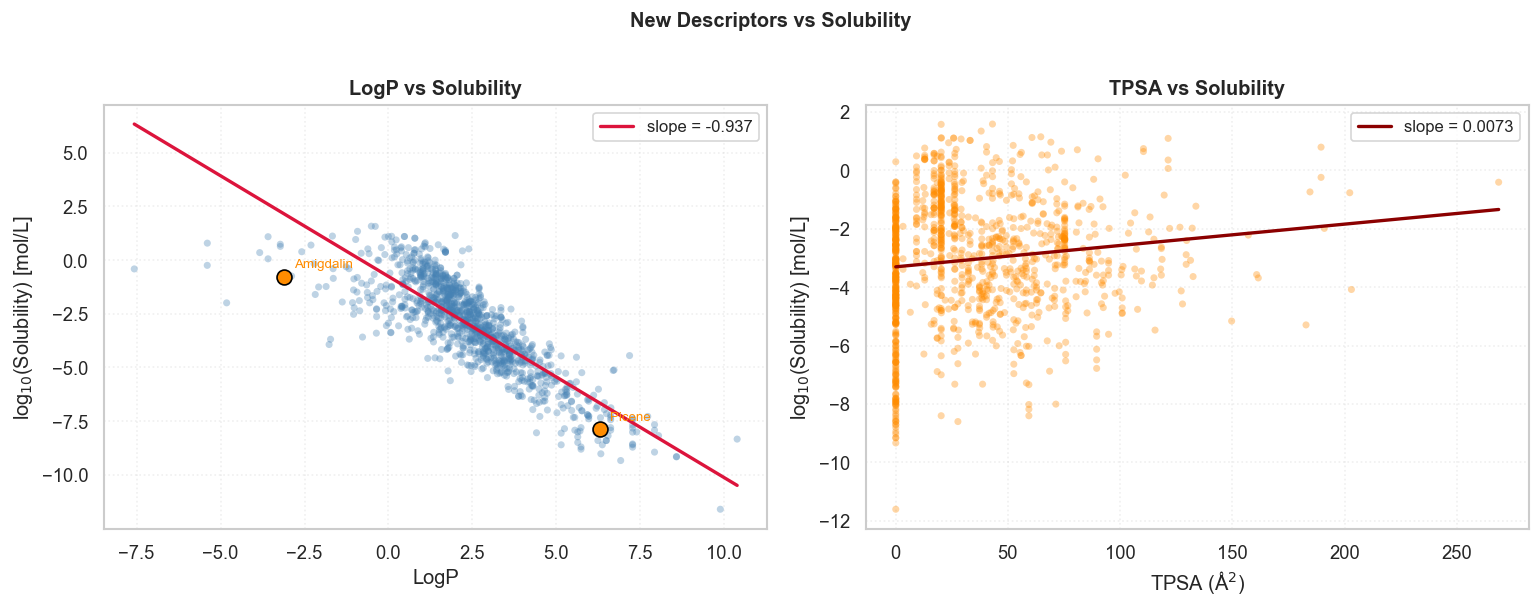

LogP slope : -0.9368  (MW slope was: -0.0131)
TPSA slope : 0.0073

Key insight:
  LogP slope (-0.94) is 72x larger (in magnitude) than MW slope (-0.013).
  LogP is a far stronger predictor of solubility than MW.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- Left panel: LogP vs log S ----
x_logp = desc_df['LogP'].values
y_logs = log_s

mask = np.isfinite(x_logp) & np.isfinite(y_logs)

axes[0].scatter(x_logp[mask], y_logs[mask],
                alpha=0.35, s=18,
                color='steelblue', edgecolors='none')

# Fit a trend line
c_logp = np.polyfit(x_logp[mask], y_logs[mask], 1)
xl = np.linspace(x_logp[mask].min(), x_logp[mask].max(), 200)
axes[0].plot(xl, np.polyval(c_logp, xl),
             color='crimson', linewidth=2,
             label=f'slope = {c_logp[0]:.3f}')

# Mark Amigdalin and Picene
for idx, name, offset in [(0,'Amigdalin',(0.3,0.4)),
                           (3,'Picene',  (0.3,0.4))]:
    axes[0].scatter(desc_df['LogP'].iloc[idx],
                    log_s[idx],
                    s=80, zorder=5,
                    color='darkorange', edgecolors='black')
    axes[0].annotate(name,
        xy=(desc_df['LogP'].iloc[idx], log_s[idx]),
        xytext=(desc_df['LogP'].iloc[idx]+offset[0],
                log_s[idx]+offset[1]),
        fontsize=8, color='darkorange')

axes[0].set_xlabel('LogP', fontsize=12)
axes[0].set_ylabel('log$_{10}$(Solubility) [mol/L]', fontsize=12)
axes[0].set_title('LogP vs Solubility', fontsize=12,
                  fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle=':')

# ---- Right panel: TPSA vs log S ----
x_tpsa = desc_df['TPSA'].values
mask2  = np.isfinite(x_tpsa) & np.isfinite(y_logs)

axes[1].scatter(x_tpsa[mask2], y_logs[mask2],
                alpha=0.35, s=18,
                color='darkorange', edgecolors='none')

c_tpsa = np.polyfit(x_tpsa[mask2], y_logs[mask2], 1)
xl2 = np.linspace(x_tpsa[mask2].min(), x_tpsa[mask2].max(), 200)
axes[1].plot(xl2, np.polyval(c_tpsa, xl2),
             color='darkred', linewidth=2,
             label=f'slope = {c_tpsa[0]:.4f}')

axes[1].set_xlabel('TPSA (\u00c5$^2$)', fontsize=12)
axes[1].set_ylabel('log$_{10}$(Solubility) [mol/L]', fontsize=12)
axes[1].set_title('TPSA vs Solubility', fontsize=12,
                  fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle=':')

plt.suptitle('New Descriptors vs Solubility',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/03_logp_tpsa_vs_solubility.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"LogP slope : {c_logp[0]:.4f}  "
      f"(MW slope was: -0.0131)")
print(f"TPSA slope : {c_tpsa[0]:.4f}")
print(f"\nKey insight:")
print(f"  LogP slope ({c_logp[0]:.2f}) is {abs(c_logp[0]/(-0.0131)):.0f}x"
      f" larger (in magnitude) than MW slope (-0.013).")
print(f"  LogP is a far stronger predictor of solubility than MW.")

## Section 7: Assemble and Save the Complete Feature Matrix

Combine original ESOL features + new RDKit descriptors.

In [11]:
# Original 7 numerical features from Day 1 (columns 1-7 of ESOL)
ORIGINAL_FEATURES = [
    'ESOL predicted log solubility in mols per litre',
    'Minimum Degree',
    'Molecular Weight',
    'Number of H-Bond Donors',
    'Number of Rings',
    'Number of Rotatable Bonds',
    'Polar Surface Area',
]

# Build the combined DataFrame
feature_df = df[['Compound ID']].copy()          # keep molecule name
feature_df = pd.concat(
    [feature_df, df[ORIGINAL_FEATURES]], axis=1  
)
feature_df = pd.concat(
    [feature_df, desc_df], axis=1                # 14 new RDKit descriptors
)
feature_df['log_s'] = log_s                      

print("=== Complete Feature Matrix ===")
print(f"  Total shape      : {feature_df.shape}")
n_ml_features = len(ORIGINAL_FEATURES) + len(desc_df.columns)
print(f"  ML features      : {n_ml_features}")
print(f"    Original (ESOL): {len(ORIGINAL_FEATURES)}")
print(f"    RDKit descriptors: {len(desc_df.columns)}")
print(f"  Target (log_s)   : 1 (not a feature)")
print(f"  Identifier       : 1 (Compound ID, not a feature)")

print(f"\nSample rows (key columns):")
show = ['Compound ID','MW','LogP','TPSA','HBD','log_s']
print(feature_df[show].head(5).round(3).to_string(index=False))

=== Complete Feature Matrix ===
  Total shape      : (1128, 23)
  ML features      : 21
    Original (ESOL): 7
    RDKit descriptors: 14
  Target (log_s)   : 1 (not a feature)
  Identifier       : 1 (Compound ID, not a feature)

Sample rows (key columns):
Compound ID      MW   LogP   TPSA  HBD  log_s
  Amigdalin 457.432 -3.108 202.32    7  -0.77
   Fenfuram 201.225  2.840  42.24    1  -3.30
     citral 152.237  2.878  17.07    0  -2.06
     Picene 278.354  6.299   0.00    0  -7.87
  Thiophene  84.143  1.748   0.00    0  -1.33


In [12]:
# 1. Save feature matrix as CSV
feature_df.to_csv('../data/features_descriptors.csv', index=False)

# 2. Save fingerprint matrix as NumPy binary
np.save('../data/morgan_fp_1024.npy', fp_matrix)

# 3. Save target variable as a simple NumPy array
np.save('../data/log_s_target.npy', log_s)

print("Files saved:")
print(f"  data/features_descriptors.csv  "
      f"-- {feature_df.shape[0]} rows x {feature_df.shape[1]} cols")
print(f"  data/morgan_fp_1024.npy        "
      f"-- shape {fp_matrix.shape}, {fp_matrix.nbytes//1024} KB")
print(f"  data/log_s_target.npy          "
      f"-- shape {log_s.shape}")

Files saved:
  data/features_descriptors.csv  -- 1128 rows x 23 cols
  data/morgan_fp_1024.npy        -- shape (1128, 1024), 1128 KB
  data/log_s_target.npy          -- shape (1128,)
